# Fase 3 - Assistente Medico Virtual

Este notebook narra o pipeline da Fase 3, importando as funcoes de
`fase3/*` (nunca duplicando a logica aqui), no mesmo espirito do notebook
`03_interpretacao_llm_cancer_mama.ipynb` da Fase 2.

**Escopo**: fine-tuning LoRA/PEFT de um LLM com dados internos (sinteticos)
do hospital, um assistente clinico com LangChain (retrieval + LLM +
guardrails) e um fluxo de decisao com LangGraph (checar exames pendentes,
sugerir conduta, emitir alertas).

Todos os dados de paciente usados aqui sao **ficticios** (`PAC-000x`), e a
amostra do MedQuAD/PubMedQA usada no fine-tuning e publica (ver
`fase3/data/sample_medquad.jsonl`).

Por padrao este notebook roda 100% offline, usando o backend `"fake"` do
LLM. Se a variavel `GROQ_API_KEY` estiver configurada no ambiente, ele usa
o backend `"groq"` de verdade nas secoes de demonstracao ao vivo.

In [1]:
import json
import os
import sys
from pathlib import Path

os.environ.setdefault("USE_TF", "0")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fase3.llm_backend import LLMUnavailableError, get_llm

BACKEND = "fake"
if os.getenv("GROQ_API_KEY"):
    try:
        get_llm("groq").invoke("teste de conectividade, responda apenas 'ok'")
        BACKEND = "groq"
    except LLMUnavailableError as exc:
        print(f"GROQ_API_KEY presente mas indisponivel ({exc}); usando backend 'fake'.")

print(f"Backend de LLM usado neste notebook: {BACKEND}")

GROQ_API_KEY presente mas indisponivel (Falha ao chamar a API da Groq: Client error '401 Unauthorized' for url 'https://api.groq.com/openai/v1/chat/completions'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401); usando backend 'fake'.
Backend de LLM usado neste notebook: fake


## 1. Dataset: preprocessing, anonimizacao e curadoria

Combina protocolos internos sinteticos (`protocolos_hospital.json`),
exemplos de prontuario ficticios (`pacientes_sinteticos.json`) e uma amostra
real do MedQuAD/PubMedQA (`sample_medquad.jsonl`), aplicando anonimizacao
por regex e curadoria (dedup + filtro de tamanho).

In [2]:
from fase3.data.build_finetuning_dataset import construir_dataset, dividir_treino_validacao

exemplos = construir_dataset()
train, val = dividir_treino_validacao(exemplos)
print(f"Total de exemplos curados: {len(exemplos)}")
print(f"Treino: {len(train)} | Validacao: {len(val)}")

por_fonte = {}
for e in exemplos:
    por_fonte[e.source_type] = por_fonte.get(e.source_type, 0) + 1
por_fonte

Total de exemplos curados: 57
Treino: 48 | Validacao: 9


{'protocolo_oncologia': 3,
 'protocolo_cirurgia': 2,
 'protocolo_enfermagem': 1,
 'protocolo_seguranca_do_paciente': 2,
 'faq_interna': 6,
 'protocolo_modelo_documento': 2,
 'exemplo_prontuario': 3,
 'assistente_clinico_sintetico': 18,
 'medquad': 12,
 'pubmedqa': 8}

In [3]:
exemplo = train[0]
print("Instrucao:", exemplo.instruction)
print("Resposta:", exemplo.output[:300], "...")
print("Fonte:", exemplo.source_type, exemplo.source_id)

Instrucao: Explique o protocolo interno: Protocolo de conduta em cancer de mama triplo negativo
Resposta: Casos com receptores de estrogenio, progesterona e HER2 negativos (triplo negativo) tem indicacao preferencial de quimioterapia neoadjuvante antes da cirurgia, com esquema baseado em antraciclina e taxano, associado a carboplatina quando ha mutacao BRCA confirmada. A resposta patologica completa dev ...
Fonte: protocolo_oncologia PROT-002


## 2. Fine-tuning LoRA/PEFT

O treinamento em si roda por linha de comando (`python -m
fase3.finetuning.train_lora`), pois depende de `torch`/`transformers`/`peft`
(`requirements-fase3.txt`), pesados demais para o ambiente padrao do
notebook/CI. Foram executados quatro experimentos reais: `distilgpt2`,
Qwen2.5-0.5B v1, Qwen2.5-0.5B v2 e Qwen2.5-1.5B. O modelo de 1,5B foi
selecionado por apresentar a melhor loss de validacao (2,1101) e a menor
perplexidade (8,249). O relatorio tecnico apresenta tambem os erros de
geracao que motivaram cada troca; loss menor, isoladamente, nao foi tratada
como evidencia de qualidade clinica.

In [4]:
summary_path = PROJECT_ROOT / "resultados" / "fase3" / "finetuning" / "qwen2.5-1.5b" / "training_summary.json"

if summary_path.exists():
    resumo = json.loads(summary_path.read_text(encoding="utf-8"))
    print(f"Modelo base: {resumo['base_model']} | LoRA r={resumo['lora_r']} alpha={resumo['lora_alpha']}")
    print(f"Modulos LoRA: {resumo['lora_target_modules']}")
    print(f"Exemplos de treino/validacao: {resumo['n_exemplos_treino']}/{resumo['n_exemplos_validacao']}")
    print(f"Perplexidade de validacao: {resumo['perplexidade_validacao']}")
    print()
    print("Perda media de treino por epoca:")
    for ponto in resumo["perda_media_por_epoca"]:
        print(f"  epoca {ponto['epoch']}: {ponto['loss_medio']:.4f}")
    print()
    print("Perda de validacao por epoca:")
    for ponto in resumo["historico_perda_validacao"]:
        print(f"  epoca {ponto['epoch']:.0f}: {ponto['eval_loss']:.4f}")
else:
    print("Resumo de treinamento nao encontrado. Rode antes:")
    print("  python -m fase3.finetuning.train_lora")

Modelo base: Qwen/Qwen2.5-1.5B-Instruct | LoRA r=8 alpha=16
Modulos LoRA: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
Exemplos de treino/validacao: 60/7
Perplexidade de validacao: 8.249

Perda media de treino por epoca:
  epoca 1: 2.3752
  epoca 2: 1.9048
  epoca 3: 1.7343

Perda de validacao por epoca:
  epoca 1: 2.3172
  epoca 2: 2.1559
  epoca 3: 2.1101


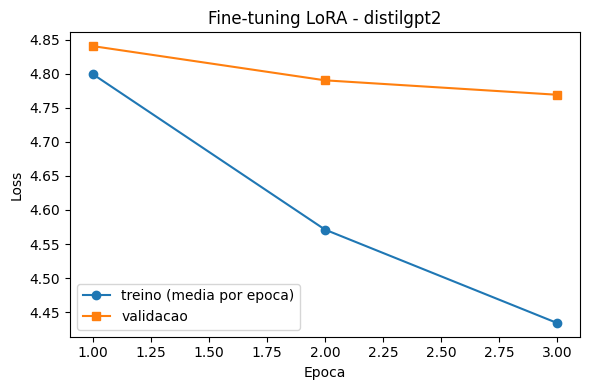

In [5]:
import matplotlib.pyplot as plt

if summary_path.exists():
    epocas_treino = [p["epoch"] for p in resumo["perda_media_por_epoca"]]
    loss_treino = [p["loss_medio"] for p in resumo["perda_media_por_epoca"]]
    epocas_val = [p["epoch"] for p in resumo["historico_perda_validacao"]]
    loss_val = [p["eval_loss"] for p in resumo["historico_perda_validacao"]]

    plt.figure(figsize=(6, 4))
    plt.plot(epocas_treino, loss_treino, marker="o", label="treino (media por epoca)")
    plt.plot(epocas_val, loss_val, marker="s", label="validacao")
    plt.xlabel("Epoca")
    plt.ylabel("Loss")
    plt.title(f"Fine-tuning LoRA - {resumo['base_model']}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 3. Retrieval sobre os protocolos internos (LangChain)

BM25 determinístico (sem embeddings, sem download de modelo) sobre
`protocolos_hospital.json`.

In [6]:
from fase3.retrieval import construir_retriever, buscar_protocolos, formatar_fontes

retriever = construir_retriever()
docs = buscar_protocolos("o que fazer com um paciente com dor forte apos a cirurgia?", retriever)
formatar_fontes(docs)

[{'id': 'PROT-004', 'titulo': 'Protocolo de manejo da dor pos-operatoria'},
 {'id': 'PROT-012',
  'titulo': 'Perguntas frequentes de medicos sobre uso do assistente virtual'},
 {'id': 'PROT-007',
  'titulo': 'Protocolo de comunicacao de resultados criticos'}]

## 4. Assistente clinico (pipeline LangChain) e guardrails

`fase3.assistant_chain.responder_pergunta_clinica` monta a chain LCEL
(`prompt | llm | StrOutputParser`), busca o contexto do paciente no mock de
EHR e aplica os guardrails de seguranca antes de devolver a resposta.

In [7]:
from fase3.assistant_chain import responder_pergunta_clinica
from fase3.llm_backend import get_llm

if BACKEND == "fake":
    llm = get_llm("fake", respostas=[
        "O protocolo institucional recomenda reavaliacao clinica e checagem dos exames pendentes antes de prosseguir.",
    ])
else:
    llm = get_llm("groq")

resultado = responder_pergunta_clinica(
    "Posso iniciar a quimioterapia hoje?", paciente_id="PAC-0001", llm=llm
)
print(resultado["resposta"])
print()
print("Fontes citadas:", resultado["fontes"])
print("Bloqueado por guardrail:", resultado["bloqueado"])

2026-07-30 19:04:12,099 INFO {"timestamp": "2026-07-30T22:04:12.099655+00:00", "event": "resposta_assistente_medico", "prompt_version": "assistente_medico_v1", "paciente_id": "PAC-0001", "pergunta": "Posso iniciar a quimioterapia hoje?", "fontes": [{"id": "PROT-008", "titulo": "Perguntas frequentes de medicos sobre conduta em cancer de mama"}, {"id": "PROT-002", "titulo": "Protocolo de conduta em cancer de mama triplo negativo"}, {"id": "PROT-006", "titulo": "Protocolo de exames pre-tratamento oncologico"}], "bloqueado": false, "motivo_bloqueio": null}


O protocolo institucional recomenda reavaliacao clinica e checagem dos exames pendentes antes de prosseguir.

Esta resposta foi gerada por um assistente automatizado com base em protocolos internos e nao substitui a avaliacao clinica presencial. Qualquer conduta ou prescricao exige validacao de um medico responsavel antes de ser aplicada ao paciente.

Fontes citadas: [{'id': 'PROT-008', 'titulo': 'Perguntas frequentes de medicos sobre conduta em cancer de mama'}, {'id': 'PROT-002', 'titulo': 'Protocolo de conduta em cancer de mama triplo negativo'}, {'id': 'PROT-006', 'titulo': 'Protocolo de exames pre-tratamento oncologico'}]
Bloqueado por guardrail: False


In [8]:
# Demonstracao do guardrail bloqueando uma sugestao de prescricao direta
from fase3.guardrails import aplicar_guardrails

exemplo_inseguro = aplicar_guardrails("Tome 500mg de dipirona agora mesmo.")
print("Bloqueado:", exemplo_inseguro.bloqueado, "| motivo:", exemplo_inseguro.motivo)
print(exemplo_inseguro.resposta)

Bloqueado: True | motivo: prescricao_direta_bloqueada
Nao posso indicar diretamente uma prescricao, dose ou tratamento. Consulte o protocolo relevante e submeta a decisao a um medico responsavel para validacao antes de qualquer conduta.


## 5. Fluxo de decisao clinica (LangGraph)

`buscar_paciente -> verificar_exames_pendentes -> sugerir_tratamento ->
checar_seguranca -> emitir_alertas -> registrar_auditoria`, com uma
bifurcacao real: se o paciente nao e encontrado, o fluxo encerra com
seguranca antes de qualquer sugestao.

In [9]:
from fase3.clinical_flow_graph import executar_fluxo_clinico

if BACKEND == "fake":
    llm_fluxo = get_llm("fake", respostas=[
        "Recomenda-se seguir o protocolo institucional relevante para o quadro descrito.",
    ])
else:
    llm_fluxo = get_llm("groq")

estado = executar_fluxo_clinico(
    "PAC-0005", "A paciente esta com febre e taquicardia, qual conduta seguir?", llm=llm_fluxo
)
print("Paciente encontrado:", estado["paciente_encontrado"])
print("Bloqueado:", estado["bloqueado"])
print()
print("Alertas para a equipe medica:")
for alerta in estado["alertas"]:
    print(" -", alerta)
print()
print("Resposta:")
print(estado["sugestao"]["resposta"])

C:\Users\marco\PycharmProjects2\tech-challenge-1\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


2026-07-30 19:04:12,380 INFO {"timestamp": "2026-07-30T22:04:12.380835+00:00", "event": "resposta_assistente_medico", "prompt_version": "assistente_medico_v1", "paciente_id": "PAC-0005", "pergunta": "A paciente esta com febre e taquicardia, qual conduta seguir?", "fontes": [{"id": "PROT-001", "titulo": "Protocolo de rastreamento e diagnostico precoce de cancer de mama"}, {"id": "PROT-008", "titulo": "Perguntas frequentes de medicos sobre conduta em cancer de mama"}, {"id": "PROT-010", "titulo": "Modelo padrao de receita e orientacoes pos-alta"}], "bloqueado": false, "motivo_bloqueio": null}


2026-07-30 19:04:12,385 INFO {"timestamp": "2026-07-30T22:04:12.385352+00:00", "event": "fluxo_clinico_concluido", "paciente_id": "PAC-0005", "paciente_encontrado": true, "alertas": ["Exames pendentes para PAC-0005: tomografia_torax_abdome.", "Alerta clinico ativo: Febre de 38.6C registrada ha 2 horas, associada a taquicardia (110 bpm)"], "bloqueado": false, "fontes": [{"id": "PROT-001", "titulo": "Protocolo de rastreamento e diagnostico precoce de cancer de mama"}, {"id": "PROT-008", "titulo": "Perguntas frequentes de medicos sobre conduta em cancer de mama"}, {"id": "PROT-010", "titulo": "Modelo padrao de receita e orientacoes pos-alta"}]}


Paciente encontrado: True
Bloqueado: False

Alertas para a equipe medica:
 - Exames pendentes para PAC-0005: tomografia_torax_abdome.
 - Alerta clinico ativo: Febre de 38.6C registrada ha 2 horas, associada a taquicardia (110 bpm)

Resposta:
Recomenda-se seguir o protocolo institucional relevante para o quadro descrito.

Esta resposta foi gerada por um assistente automatizado com base em protocolos internos e nao substitui a avaliacao clinica presencial. Qualquer conduta ou prescricao exige validacao de um medico responsavel antes de ser aplicada ao paciente.


## 6. Avaliacao do assistente

Rubrica deterministica (fontes citadas e validas, ausencia de protocolo ou
numero inventado, adequacao clinica, disclaimer, ausencia de PII e nenhuma
prescricao direta vazando) sobre seis perguntas parafraseadas —
mesma filosofia do `src/evaluate_llm.py` da Fase 2, sem usar um segundo LLM
como juiz. Na execucao local final, o pipeline obteve score 1,00, mas a
taxa de fallback foi 100% e a taxa de saida da LLM aceita sem fallback foi
0%. O resultado final seguro nao e atribuido isoladamente ao LoRA.

In [10]:
from fase3.evaluate_assistant import executar_avaliacao, salvar_resultados

linhas = executar_avaliacao(BACKEND)
salvar_resultados(linhas)

for linha in linhas:
    print(f"{str(linha['paciente_id']):>10} | bloqueado={linha['bloqueado']!s:5} | score={linha['score_objetivo']:.2f} | {linha['pergunta'][:50]}")

score_medio = sum(l["score_objetivo"] for l in linhas) / len(linhas)
print(f"\nScore objetivo medio: {score_medio:.2f}")

2026-07-30 19:04:12,404 INFO {"timestamp": "2026-07-30T22:04:12.404524+00:00", "event": "resposta_assistente_medico", "prompt_version": "assistente_medico_v1", "paciente_id": "PAC-0001", "pergunta": "Posso iniciar a quimioterapia neoadjuvante hoje?", "fontes": [{"id": "PROT-002", "titulo": "Protocolo de conduta em cancer de mama triplo negativo"}, {"id": "PROT-008", "titulo": "Perguntas frequentes de medicos sobre conduta em cancer de mama"}, {"id": "PROT-006", "titulo": "Protocolo de exames pre-tratamento oncologico"}], "bloqueado": false, "motivo_bloqueio": null}


2026-07-30 19:04:12,409 INFO {"timestamp": "2026-07-30T22:04:12.409545+00:00", "event": "resposta_assistente_medico", "prompt_version": "assistente_medico_v1", "paciente_id": "PAC-0003", "pergunta": "O que fazer com o achado BI-RADS 4 pendente de biopsia?", "fontes": [{"id": "PROT-008", "titulo": "Perguntas frequentes de medicos sobre conduta em cancer de mama"}, {"id": "PROT-007", "titulo": "Protocolo de comunicacao de resultados criticos"}, {"id": "PROT-012", "titulo": "Perguntas frequentes de medicos sobre uso do assistente virtual"}], "bloqueado": false, "motivo_bloqueio": null}


2026-07-30 19:04:12,414 INFO {"timestamp": "2026-07-30T22:04:12.414060+00:00", "event": "resposta_assistente_medico", "prompt_version": "assistente_medico_v1", "paciente_id": "PAC-0005", "pergunta": "A paciente esta com febre e taquicardia, qual conduta seguir?", "fontes": [{"id": "PROT-001", "titulo": "Protocolo de rastreamento e diagnostico precoce de cancer de mama"}, {"id": "PROT-008", "titulo": "Perguntas frequentes de medicos sobre conduta em cancer de mama"}, {"id": "PROT-010", "titulo": "Modelo padrao de receita e orientacoes pos-alta"}], "bloqueado": true, "motivo_bloqueio": "prescricao_direta_bloqueada"}


2026-07-30 19:04:12,419 INFO {"timestamp": "2026-07-30T22:04:12.419596+00:00", "event": "resposta_assistente_medico", "prompt_version": "assistente_medico_v1", "paciente_id": "PAC-0006", "pergunta": "A dor pos-operatoria persiste em 7/10, o que fazer?", "fontes": [{"id": "PROT-012", "titulo": "Perguntas frequentes de medicos sobre uso do assistente virtual"}, {"id": "PROT-004", "titulo": "Protocolo de manejo da dor pos-operatoria"}, {"id": "PROT-005", "titulo": "Protocolo de alta hospitalar pos-mastectomia"}], "bloqueado": false, "motivo_bloqueio": null}


2026-07-30 19:04:12,424 INFO {"timestamp": "2026-07-30T22:04:12.424116+00:00", "event": "resposta_assistente_medico", "prompt_version": "assistente_medico_v1", "paciente_id": "PAC-9999", "pergunta": "Qual o protocolo para esse paciente?", "fontes": [{"id": "PROT-006", "titulo": "Protocolo de exames pre-tratamento oncologico"}, {"id": "PROT-012", "titulo": "Perguntas frequentes de medicos sobre uso do assistente virtual"}, {"id": "PROT-008", "titulo": "Perguntas frequentes de medicos sobre conduta em cancer de mama"}], "bloqueado": false, "motivo_bloqueio": null}


2026-07-30 19:04:12,428 INFO {"timestamp": "2026-07-30T22:04:12.428148+00:00", "event": "resposta_assistente_medico", "prompt_version": "assistente_medico_v1", "paciente_id": null, "pergunta": "Quais exames sao obrigatorios antes de iniciar quimioterapia sistemica?", "fontes": [{"id": "PROT-008", "titulo": "Perguntas frequentes de medicos sobre conduta em cancer de mama"}, {"id": "PROT-006", "titulo": "Protocolo de exames pre-tratamento oncologico"}, {"id": "PROT-002", "titulo": "Protocolo de conduta em cancer de mama triplo negativo"}], "bloqueado": false, "motivo_bloqueio": null}


  PAC-0001 | bloqueado=False | score=1.00 | Posso iniciar a quimioterapia neoadjuvante hoje?
  PAC-0003 | bloqueado=False | score=1.00 | O que fazer com o achado BI-RADS 4 pendente de bio
  PAC-0005 | bloqueado=True  | score=1.00 | A paciente esta com febre e taquicardia, qual cond
  PAC-0006 | bloqueado=False | score=1.00 | A dor pos-operatoria persiste em 7/10, o que fazer
  PAC-9999 | bloqueado=False | score=1.00 | Qual o protocolo para esse paciente?
      None | bloqueado=False | score=1.00 | Quais exames sao obrigatorios antes de iniciar qui

Score objetivo medio: 1.00


## 7. Conclusao

O pipeline cobre os quatro requisitos obrigatorios da Fase 3: fine-tuning
LoRA/PEFT com dados internos (sinteticos + amostra real do
MedQuAD/PubMedQA), um assistente LangChain com retrieval sobre protocolos e
consulta a um mock de EHR estruturado, guardrails de seguranca com
explainability (fontes citadas) e logging de auditoria, e um fluxo de
decisao automatizado com LangGraph. O Qwen2.5-1.5B + LoRA foi selecionado
entre quatro experimentos, mas a geracao bruta ainda exige mais dados,
modelo maior e validacao clinica externa. Detalhes de arquitetura em
`docs/arquitetura_fase3.md` e a analise completa em
`relatorio_tecnico_fase3.md`.